# Báo cáo Phân tích Khám phá (EDA) – Dự đoán Customer Churn
---
**Mô tả dự án:**  
Dự án thực hiện Phân tích Khám phá Dữ liệu (EDA) chuyên sâu cho bài toán dự báo tỷ lệ rời bỏ dịch vụ của khách hàng (Customer Churn), dựa trên bộ dữ liệu tổng hợp từ Kaggle Playground Series, là chuỗi các cuộc thi Machine Learning hàng tháng do Kaggle tổ chức, với vai trò như một "sân tập" (Playground) để cộng đồng cọ xát và mài dũa kỹ năng.

**Mục tiêu chính:**  
- Kiểm tra chất lượng dữ liệu: Rà soát dữ liệu khuyết thiếu (missing values), dữ liệu trùng lặp và cấu trúc của tập dữ liệu gốc.
- Đánh giá mức độ mất cân bằng: Phân tích tỷ lệ của biến mục tiêu (`Churn`) để có phương án chia tập huấn luyện/kiểm thử hợp lý.
- Khám phá các đặc trưng: Dùng biểu đồ và ma trận tương quan để tìm ra những yếu tố có ảnh hưởng lớn nhất đến quyết định rời đi của khách hàng
- So sánh tập Train và Test: Đối chiếu phân phối giữa hai tập dữ liệu nhằm đảm bảo tính đồng nhất, tránh hiện tượng trôi dạt dữ liệu (data drift) khi chạy mô hình.

**Định hướng kết quả:**  
Cung cấp các kết luận phân tích cụ thể để định hình chiến lược tiền xử lý dữ liệu (preprocessing), thiết kế đặc trưng (feature engineering) và xây dựng mô hình học máy đạt hiệu quả tối ưu nhất.

---

## Các thành viên nhóm 14
| Tên          | Mã số sinh viên    |
|----------------|--------------|
| Nguyễn Lan Anh       | 24280006      |
| Lê Văn Đức (Trưởng nhóm) | 24280010|
| Trần Quang Huy| 24280015|
| Phạm Tiến Phát    | 24280018 | 
|    Hoàng Gia Bảo | 24280049      |
| Đặng Hoàng Khang| 24280076|
| Nguyễn Tiến Phát | 24280093|

## 0. Setup môi trường làm việc (Environment Setup)

### 0.1 Import thư viện (Library Imports)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import matplotlib.ticker as mtick

In [2]:
from IPython.display import display
from scipy.stats import chi2_contingency

### 0.2 Cấu hình hiển thị và đồ thị (Display & Styling Configuration)

In [3]:
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid")

### 0.3 Tải dữ liệu cần thiết (Data Loading)

In [4]:
print("Đang tải dữ liệu từ Kaggle...")
path = kagglehub.competition_download("playground-series-s6e3")

df_train = pd.read_csv(os.path.join(path, 'train.csv'))
df_test = pd.read_csv(os.path.join(path, 'test.csv'))

print("Tải dữ liệu thành công!")
file_summary = pd.DataFrame({
    "Stt": [1, 2],
    "File": ["train.csv", "test.csv"],
    "Số hàng": [len(df_train), len(df_test) if df_test is not None else np.nan],
    "Số cột": [df_train.shape[1], df_test.shape[1] if df_test is not None else np.nan],
})
print("Mô tả kích thước dữ liệu:")
display(file_summary.set_index("Stt").rename_axis(None))

Đang tải dữ liệu từ Kaggle...
Tải dữ liệu thành công!
Mô tả kích thước dữ liệu:


,File,Số hàng,Số cột
1,train.csv,594194,21
2,test.csv,254655,20


 **Note:** Khi quan sát kích thước dữ liệu, ta có thể thấy file `train.csv` dư 1 cột hơn so với file `test.csv`. Dự đoán ban đầu là biến mục tiêu (target) là cột thiếu

In [5]:
df_train_copy = df_train.copy()

In [6]:
df_train_copy.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1000,1653.8500,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5000,3778.2000,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4000,5841.3500,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.7000,70.7000,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.4500,70.4500,Yes


In [7]:
df_test_copy = df_test.copy()

In [8]:
df_test_copy.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.5500,8061.5000
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.8000,1336.5000
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.5500,633.5500
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.1000,6457.1500
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.3500,1233.6500


**Note:** Kiểm tra dữ liệu đầu vào

## 1. Tiền xử lí dữ liệu (Data Preprocessing)

* **Tiền xử lí dữ liệu: Thông qua các bước dưới đây để làm sạch và chuẩn hóa dữ liệu** 
1. Kiểm tra dữ liệu rỗng (Completeness Check)
2. Kiểm tra tính trùng lặp (Validity & Consistency Check)
3. Kiểm tra tổng quan dữ liệu (Overview)  


### 1.1 Tiền xử lí dữ liệu training (Training Data Preprocessing)

In [9]:
print("1. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):")
if df_train_copy.isnull().sum().sum() == 0:
    print("Không có dữ liệu rỗng trong tập dữ liệu training.csv.")
else:
    print("Tồn tại dữ liệu rỗng trong tập dữ liệu training.csv, cụ thể phân bố dữ liệu rỗng:")
    print(df_train_copy.isnull().sum())

1. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):
Không có dữ liệu rỗng trong tập dữ liệu training.csv.


In [10]:
print("2. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):")
if df_train_copy.duplicated().sum() == 0:
    print("Không có dữ liệu trùng lặp trong tập dữ liệu.")
else:
    print("Tồn tại", df_train.duplicated().sum(), "hàng dữ liệu trùng lặp trong tập dữ liệu.")


2. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):
Không có dữ liệu trùng lặp trong tập dữ liệu.


In [11]:
print("3. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):")
df_train_copy.info()

3. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):
<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-nul

### 1.2 Tiền xử lí dữ liệu test (Test Data Preprocessing)

In [12]:
print("1. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):")
if df_test_copy.isnull().sum().sum() == 0:
    print("Không có dữ liệu rỗng trong tập dữ liệu test.csv.")
else:
    print("Tồn tại dữ liệu rỗng trong tập dữ liệu test.csv, cụ thể phân bố dữ liệu rỗng:")
    print(df_test_copy.isnull().sum())

1. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):
Không có dữ liệu rỗng trong tập dữ liệu test.csv.


In [13]:
print("2. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):")
if df_test_copy.duplicated().sum() == 0:
    print("Không có dữ liệu trùng lặp trong tập dữ liệu test.csv.")
else:
    print("Tồn tại", df_test_copy.duplicated().sum(), "hàng dữ liệu trùng lặp trong tập dữ liệu test.csv.")


2. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):
Không có dữ liệu trùng lặp trong tập dữ liệu test.csv.


In [14]:
print("3. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):")
df_test_copy.info()

3. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):
<class 'pandas.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  str    
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  str    
 4   Dependents        254655 non-null  str    
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  str    
 7   MultipleLines     254655 non-null  str    
 8   InternetService   254655 non-null  str    
 9   OnlineSecurity    254655 non-null  str    
 10  OnlineBackup      254655 non-null  str    
 11  DeviceProtection  254655 non-null  str    
 12  TechSupport       254655 non-null  str    
 13  StreamingTV       254655 non-null  str    
 14  StreamingMovies   254655 non-null  str    
 15  Contract          254655 non-nul

**Note:** Dự đoán ban đầu được đặt ra là chính xác, cột thiếu đi trong `test.csv` so với `train.csv` là cột `Churn`, là target của dự án. Ta có thể thấy rõ hơn thông qua cell dưới đây.

In [15]:
schema = pd.DataFrame({
    "train_columns": df_train_copy.columns,
    "train_dtypes": df_train_copy.dtypes.astype(str).values,
    "in_test": [col in df_test_copy.columns for col in df_train_copy.columns],
    "test_dtypes": [str(df_test_copy[col].dtype) if col in df_test_copy.columns else None for col in df_train_copy.columns],
})
display(schema)

,train_columns,train_dtypes,in_test,test_dtypes
0,id,int64,True,int64
1,gender,str,True,str
2,SeniorCitizen,int64,True,int64
3,Partner,str,True,str
4,Dependents,str,True,str
5,tenure,int64,True,int64
6,PhoneService,str,True,str
7,MultipleLines,str,True,str
8,InternetService,str,True,str
9,OnlineSecurity,str,True,str


* **Mô tả**

| Tên cột | Mô tả |
| :--- | :--- |
|`train_columns`| Tên cột xuất hiện trong file `train.csv`|
|`train_dtypes`| Kiểu dữ liệu của cột này trong file `train.csv`|
|`in_test`| Cột này có xuất hiện trong file `test.csv`?|
|`train_dtypes`| Kiểu dữ liệu của cột này trong file `test.csv`|



## 2. Mô tả dữ liệu training (Training Dataset Overview)

### 2.1 Mô tả sơ bộ (Preliminary Overview)

| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `id` | int64 | Mã định danh của khách hàng |
| `gender` | object | Giới tính |
| `SeniorCitizen` | int64 | Khách hàng có là người cao tuổi (>= 65 tuổi)? (`1`: Có, `0`: Không)|
| `Partner` | object | Khách hàng có sống chung với vợ/chồng?|
| `Dependents` | object | Khách hàng có cần được chăm sóc?|
| `tenure` | int64 | **Thời gian sử dụng dịch vụ:** Thời gian khách hàng đã gắn bó và sử dụng dịch vụ, tính theo tháng|
| `PhoneService` | object | Khách hàng có đăng ký dịch vụ điện thoại?|
| `MultipleLines` | object | Khách hàng có sử dụng nhiều đường dây điện thoại cùng lúc?|
| `InternetService` | object | Loại dịch vụ Internet mà khách hàng đang dùng|
| `OnlineSecurity` | object | Khách hàng có đăng ký gói bảo mật mạng trực tuyến?|
| `OnlineBackup` | object | Khách hàng có đăng ký gói sao lưu dữ liệu đám mây?|
| `DeviceProtection` | object | Khách hàng có mua gói bảo vệ thiết bị?|
| `TechSupport` | object | Khách hàng có đăng ký dịch vụ hỗ trợ kỹ thuật?|
| `StreamingTV` | object | Khách hàng có sử dụng Internet để xem truyền hình?|
| `StreamingMovies` | object | Khách hàng có sử dụng Internet để xem phim trực tuyến?|
| `Contract` | object | Loại hợp đồng thanh toán khách hàng đã ký?|
| `PaperlessBilling` | object | Khách hàng có nhận hóa đơn điện tử?|
| `PaymentMethod` | object | Phương thức thanh toán|
| `MonthlyCharges` | float64 | **Cước phí tháng**|
| `TotalCharges` | float64 | **Tổng cước phí**|
| `Churn` | object | **Biến mục tiêu (Target):** Khách hàng có rời bỏ dịch vụ không?|

In [16]:
df_train_copy['SeniorCitizen'] = df_train_copy['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

**Note:** Đưa biến SeniorCitizen về hai giá trị Yes/No thay cho 1/0 như trong dữ liệu gốc để đồng nhất so với các biến trả về 2 giá trị Yes/No khác.

### 2.2 Phân loại biến (Feature Classification)
Các biến được phân loại dựa trên đặc điểm của chúng để đưa vào 4 nhóm phân biệt:
- Biến định danh (Identifiers)
- Biến định tính (Categorical Features)
- Biến định lượng (Numerical Features)
- Biến mục tiêu (Target): Là mục tiêu của dự án này, biến `Churn`


In [17]:
identifier_data= df_train_copy['id']
identifier_features = [identifier_data.name]

print(f'Có {len(identifier_features)} biến định danh:','\n')
print(identifier_features)


Có 1 biến định danh: 

['id']


**Note:** Biến định danh như tên gọi, định danh một đối tượng, không mang ý nghĩa về thống kê nhưng rất có ích trong quá trình kiểm tra các dữ liệu trống và dữ liệu lỗi giai đoạn tiền xử lí dữ liệu. 

In [18]:
categorical_data=df_train_copy.select_dtypes(include=['object','str']).drop('Churn', axis=1, errors='ignore')
categorical_features=categorical_data.columns.tolist()

print(f'Có {len(categorical_features)} biến định tính:','\n')
print(categorical_features)

Có 16 biến định tính: 

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Note:** Biến định tính biểu diễn tính chất của đặc trưng mà nó thể hiện, có tác dụng phân loại. Tuy nhiên, để phù hợp với quá trình tìm hệ số tương quan giữa chúng so với biến mục tiêu, và quá trình huấn luyện mô hình sau này, quá trình phân loại cần được thực hiện

In [19]:
numerical_data = df_train_copy.select_dtypes(include='number').drop('id', axis=1, errors='ignore')
numerical_features = numerical_data.columns.tolist()

print(f'Có {len(numerical_features)} biến định lượng:\n')
print(numerical_features)

Có 3 biến định lượng:

['tenure', 'MonthlyCharges', 'TotalCharges']


**Note:** Biến định lượng biểu diễn độ lớn của đặc trưng mà nó thể hiện. Có một điều lưu ý rằng biến `tenure` chỉ thời gian gắn bó với dịch vụ nên ta có thể chia thành từng giai đoạn, tức thay đổi biến định lượng `tenure` thành biến định tính `timestamp` để phù hợp hơn với thực tế. Nhưng trước hết ở quá trình mô tả và trực quan hóa các đặc trưng, ta giữ nguyên biến này.

In [20]:
target_data = df_train_copy['Churn']        
target_features = [target_data.name]
print(f'Có {len(target_features)} biến mục tiêu:','\n')
print(target_features)

Có 1 biến mục tiêu: 

['Churn']


**Note:** Ta phân loại `Churn` ra thành 1 biến mục tiêu riêng, để trước tiên mô tả và trực quan hóa riêng từng loại biến: biến định lượng, biến định tính và biến mục tiêu. Sau khi hoàn thành quá trình này, ta mới ghép nối biến mục tiêu `Churn` với các biến còn lại để tìm ra các quy luật đặc trưng. 

## 3. Sàng lọc giá trị vô lý và ngoại lệ (Unreasonable Values & Outliers Screening).

### 3.1 Kiểm tra các biến định tính (Categorical Features Sanity Check)

In [21]:
def categorical_sanity_checks(df, df_name="train.csv"):
    internet_dependent_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]
    phone_dependent_cols = ["MultipleLines"]

    checks = {
        "Sử dụng dịch vụ internet nhưng không có internet": int(
            df.loc[df["InternetService"].eq("No"), internet_dependent_cols]
            .ne("No internet service").any(axis=1).sum()
        ),
        "Sử dụng internet nhưng không có dịch vụ internet": int(
            df.loc[~df["InternetService"].eq("No"), internet_dependent_cols]
            .eq("No internet service").any(axis=1).sum()
        ),
        "Sử dụng dịch vụ điện thoại nhưng không có điện thoại": int(
            df.loc[df["PhoneService"].eq("No"), phone_dependent_cols]
            .ne("No phone service").any(axis=1).sum()
        ),
        "Sử dụng điện thoại nhưng không có dịch vụ điện thoại": int(
            df.loc[df["PhoneService"].eq("Yes"), phone_dependent_cols]
            .eq("No phone service").any(axis=1).sum()
        ),
    }
    
    print(f"--- Kiểm tra biến phân loại từ file {df_name} ---")
    display(pd.Series(checks).to_frame("Số lỗi phát hiện tương ứng"))

**Note:** Hàm được sử dụng để rà soát lỗi logic chéo giữa các nhóm biến định tính có liên hệ mật thiết với nhau:
   - Nhóm dịch vụ Internet: Kiểm tra mâu thuẫn giữa cột InternetService và các dịch vụ đi kèm (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies). Ví dụ: Trạng thái là "Không có Internet" nhưng các dịch vụ đi kèm lại đang hiển thị "Có".
   - Nhóm dịch vụ Điện thoại: Kiểm tra mâu thuẫn tương tự giữa PhoneService và MultipleLines.

In [22]:
categorical_sanity_checks(df_train_copy, "train.csv")

--- Kiểm tra biến phân loại từ file train.csv ---


,Số lỗi phát hiện tương ứng
Sử dụng dịch vụ internet nhưng không có internet,0
Sử dụng internet nhưng không có dịch vụ internet,0
Sử dụng dịch vụ điện thoại nhưng không có điện thoại,0
Sử dụng điện thoại nhưng không có dịch vụ điện thoại,0


**Note:** Gọi lại hàm để kiểm tra lỗi logic biến định tính trong file `train.csv`. Không có lỗi nào được phát hiện.

In [23]:
categorical_sanity_checks(df_test_copy, "test.csv")

--- Kiểm tra biến phân loại từ file test.csv ---


,Số lỗi phát hiện tương ứng
Sử dụng dịch vụ internet nhưng không có internet,0
Sử dụng internet nhưng không có dịch vụ internet,0
Sử dụng dịch vụ điện thoại nhưng không có điện thoại,0
Sử dụng điện thoại nhưng không có dịch vụ điện thoại,0


**Note:** Gọi lại hàm để kiểm tra lỗi logic biến định tính trong file `test.csv`. Không có lỗi nào được phát hiện.

**Nhận xét:** Không xuất hiện giá trị không hợp lệ của các biến định lượng trong cả 2 file `train.csv` và `test.csv`. Ta tiếp tục kiểm tra với các biến định lượng.

### 3.2 Kiểm tra các biến định lượng (Numerical Features Sanity Check)

In [24]:
def numerical_sanity_checks(df, df_name="train.csv"):

    checks = {
        "Số tháng sử dụng dịch vụ không nguyên dương": int(((df["tenure"] <= 0) | (df["tenure"] % 1 != 0)).sum()),
        "Giá cước hàng tháng không dương": int((df["MonthlyCharges"] <= 0).sum()),
        "Tổng cước không dương": int((pd.to_numeric(df["TotalCharges"], errors='coerce') <= 0).sum())
    }
    
    print(f"--- Kiểm tra biến định lượng từ file {df_name} ---")
    display(pd.Series(checks).to_frame("Số lỗi phát hiện tương ứng"))

**Note:** Hàm được sử dụng để rà soát lỗi logic của giữa các nhóm biến định lượng:
   - Thời gian sử dụng dịch vụ (`tenure`): Yêu cầu là số nguyên dương
   - Giá cước hàng tháng (`MonthlyCharges`): Yêu cầu không âm
   - Tổng cước (`TotalCharges`): Yêu cầu không âm

In [25]:
numerical_sanity_checks(df_train_copy, "train.csv")

--- Kiểm tra biến định lượng từ file train.csv ---


,Số lỗi phát hiện tương ứng
Số tháng sử dụng dịch vụ không nguyên dương,0
Giá cước hàng tháng không dương,0
Tổng cước không dương,0


**Note:** Gọi lại hàm để kiểm tra lỗi logic biến định lượng trong file `train.csv`. Không có lỗi nào được phát hiện.

In [26]:
numerical_sanity_checks(df_test_copy, "test.csv")

--- Kiểm tra biến định lượng từ file test.csv ---


,Số lỗi phát hiện tương ứng
Số tháng sử dụng dịch vụ không nguyên dương,0
Giá cước hàng tháng không dương,0
Tổng cước không dương,0


**Note:** Gọi lại hàm để kiểm tra lỗi logic biến định lượng trong file `test.csv`. Không có lỗi nào được phát hiện.

**Nhận xét:** Không xuất hiện giá trị không hợp lệ của các biến định lượng trong cả 2 file `train.csv` và `test.csv`. Ta thực hiện trực quan hóa phân bố khách hàng theo các biến định lượng bằng đồ thị boxplot để loại bỏ các giá trị ngoại lai (outliers)

### 3.3. Trực quan hóa Boxplot và Xử lý giá trị ngoại lai (outliers)

**Note:** Mục tiêu của phần này là phân tích và trực quan hóa các biến định lượng bằng đồ thị Boxplot nhằm tìm kiếm, đánh giá và có phương án xử lý (capping) các giá trị ngoại lai nếu có, tránh làm nhiễu mô hình dự đoán."

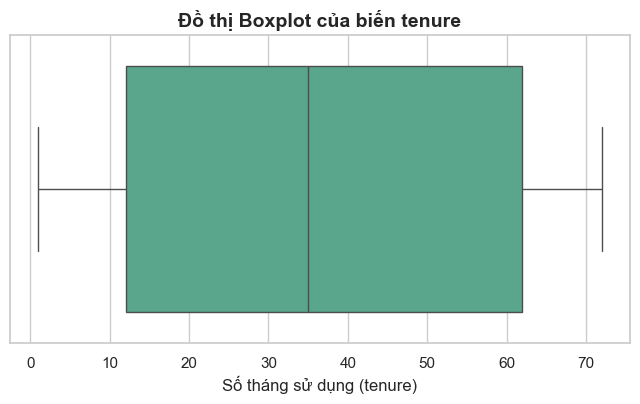

In [27]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_train_copy, x='tenure', color='#4CB391')
plt.title('Đồ thị Boxplot của biến tenure', fontsize=14, fontweight='bold')
plt.xlabel('Số tháng sử dụng (tenure)', fontsize=12)
plt.show()

**Note:** Khi xét biến `tenure`, tất cả các quan sát đều thuộc khoảng giá trị hợp lệ (inner fences).

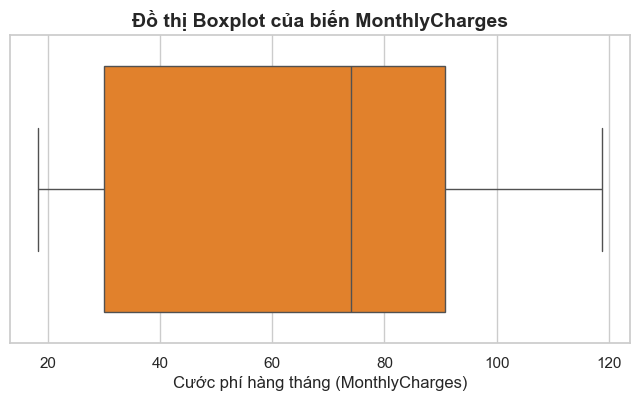

In [28]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_train_copy, x='MonthlyCharges', color='#FF7F0E')
plt.title('Đồ thị Boxplot của biến MonthlyCharges', fontsize=14, fontweight='bold')
plt.xlabel('Cước phí hàng tháng (MonthlyCharges)', fontsize=12)
plt.show()

**Note:** Khi xét biến `MonthlyCharges`, tất cả các quan sát đều thuộc khoảng giá trị hợp lệ (inner fences).

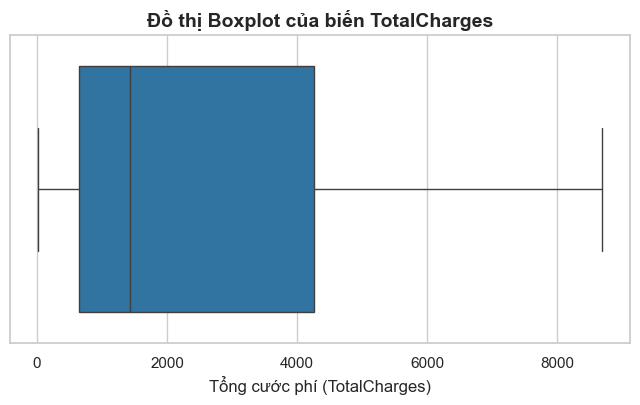

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_train_copy, x='TotalCharges', color='#1F77B4')
plt.title('Đồ thị Boxplot của biến TotalCharges', fontsize=14, fontweight='bold')
plt.xlabel('Tổng cước phí (TotalCharges)', fontsize=12)
plt.show()

**Note:** Khi xét biến `TotalCharges`, tất cả các quan sát đều thuộc khoảng giá trị hợp lệ (inner fences).

**Nhận xét:** Bằng trực quan hóa, ta nhận thấy rằng tất cả quan sát đều nằm trong khoảng không có điểm ngoại lai (Non-outlier region) của cả ba biến định lượng `tenure`,`MonthlyCharges`,`TotalCharges`. Điều này được thể hiện rõ hơn thông qua hàm dưới đây

In [30]:
def detect_outliers_bounds(train_df, columns):
    
    for col in columns:
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_count = ((train_df[col] < lower_bound) | (train_df[col] > upper_bound)).sum()

        print(f"Số lượng điểm ngoại lai ứng với biến '{col}': {outliers_count} biến\n")

**Note:** Hàm thực hiện tìm khoảng phạm vi dữ liệu hợp lệ (Valid Data Range), sau đó đếm số điểm ngoại lai ứng với từng biến

In [31]:
detect_outliers_bounds(df_train_copy, ['tenure'])

Số lượng điểm ngoại lai ứng với biến 'tenure': 0 biến



In [32]:
detect_outliers_bounds(df_train_copy, ['MonthlyCharges'])

Số lượng điểm ngoại lai ứng với biến 'MonthlyCharges': 0 biến



In [33]:
detect_outliers_bounds(df_train_copy, ['TotalCharges'])

Số lượng điểm ngoại lai ứng với biến 'TotalCharges': 0 biến



**Nhận xét:** Kết quả kiểm tra chéo bằng trực quan (Boxplot) và định lượng (phương pháp IQR) đều xác nhận 3 biến `tenure`, `MonthlyCharges`, và `TotalCharges` không chứa điểm ngoại lai (outliers). Dữ liệu phân phối tự nhiên trong giới hạn an toàn, hoạt động xử lý thêm (capping/dropping) không được thực hiện.

## 4. Mô tả và trực quan hóa các đặc trưng (Feature Analysis & Visualization)

**Mô tả, trực quan hóa các biến định tính, định lượng và biến mục tiêu, để chuẩn bị cho phần phân tích tương quan (Correlation Analysis)**

### 4.1 Biến định lượng (Numerical Features)

**Phân tích tổng quan các biến định lượng**

In [34]:
numerical_data.var()

tenure               628.0999
MonthlyCharges       965.1861
TotalCharges     5540923.8793
dtype: float64

**Note:** Phương sai của các biến định lượng, có thể thấy dữ liệu phân bố khá rộng.

In [35]:
numerical_data.skew()

tenure            0.0631
MonthlyCharges   -0.2895
TotalCharges      0.9092
dtype: float64

**Note:** Về tổng quan, dữ liệu phân bố khá đối xứng, ít bị lệch.

In [36]:
numerical_data.nunique()

tenure               72
MonthlyCharges     1921
TotalCharges      31910
dtype: int64

**Note:**
- Biến `tenture` chỉ thời gian sử dụng dịch vụ, tính theo tháng, là các giá trị nguyên dương nên chỉ phân bố trong khoảng nhỏ xác định.
- Biến `MonthlyCharges`,`TotalCharges` là cước phí theo tháng và tổng cước phí nên phân bố rất rộng, và là nguồn dữ liệu quý giá để tìm ra quy luật đặc trưng khi huấn luyện mô hình. Ta cần đi sâu vào hai biến này hơn khi thêm thuộc tính `Churn`, bằng trực quan hóa sử dụng biểu đồ cột 

**Trực quan hóa các biến định lượng bằng đồ thị Histogram để quan sát phân bố**

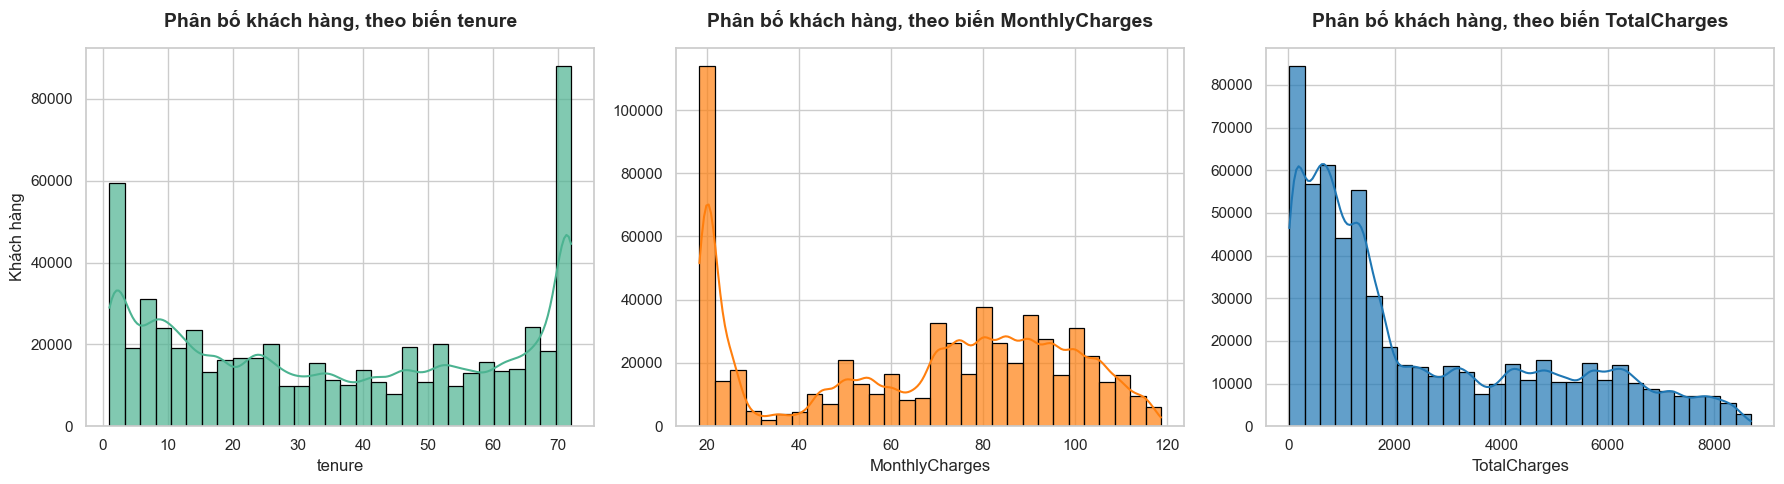

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
colors = ['#4CB391', '#FF7F0E', '#1F77B4'] 

for i, col in enumerate(numerical_features):
    sns.histplot(data=df_train_copy, x=col, ax=axes[i], bins=30, kde=True, color=colors[i], edgecolor='black', alpha=0.7)
    
    axes[i].set_title(f'Phân bố khách hàng, theo biến {col}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Khách hàng' if i == 0 else '', fontsize=12)
plt.tight_layout()
plt.show()

**Note:** Trực quan hóa phân bố khách hàng theo các biến định lượng, tính trên đầu người.

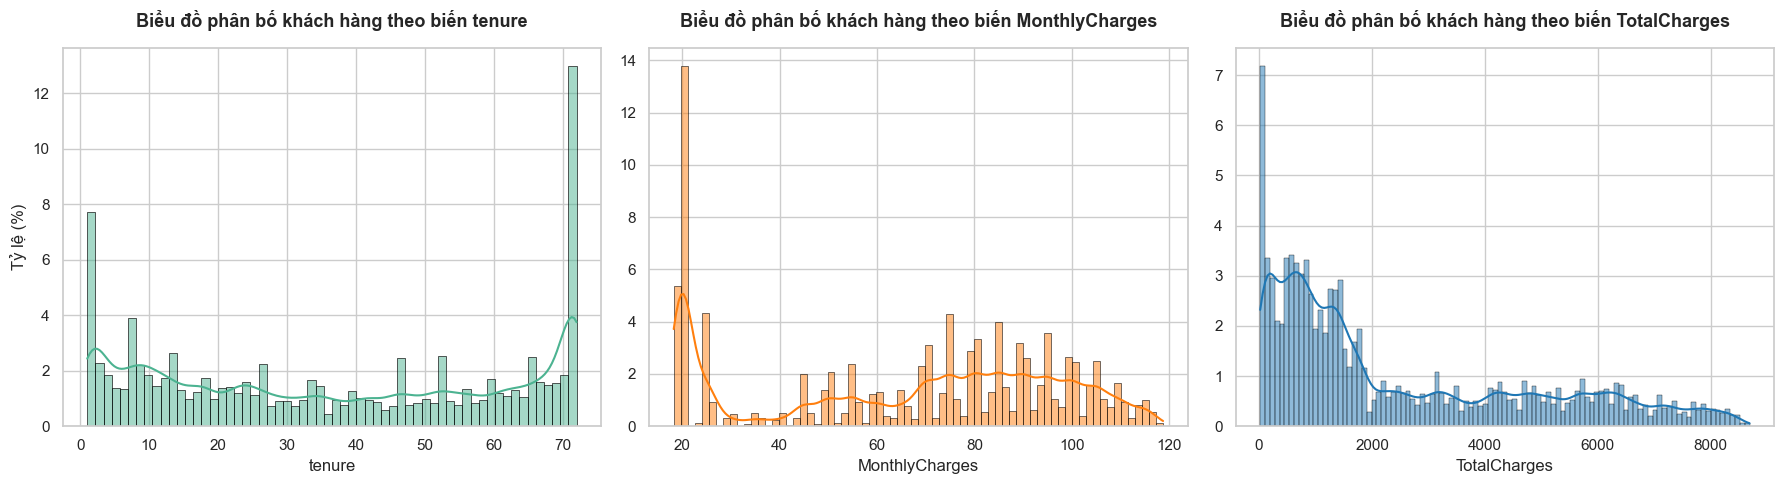

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

colors = ['#4CB391', '#FF7F0E', '#1F77B4'] 

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df_train_copy, 
        x=col, 
        ax=axes[i], 
        color=colors[i], 
        stat='percent', 
        kde=True, 
        alpha=0.5, 
        edgecolor='black'
    )
    
    axes[i].set_title(f'Biểu đồ phân bố khách hàng theo biến {col}', fontsize=13, fontweight='bold', pad=15)
    axes[i].set_xlabel(col, fontsize=12)
    
    if i == 0:
        axes[i].set_ylabel('Tỷ lệ (%)', fontsize=12)
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

**Note:** Trực quan hóa phân bố khách hàng theo các biến định lượng, tính trên phần trăm(%).

**Nhận xét:** Về đặc trưng phân bố từng biến định lượng:
-  Biến `tenure` (thời gian gắn bó): Có dạng **phân phối hai đỉnh (Bimodal Distribution)**. Khách hàng tập trung chủ yếu ở hai biên, gồm nhóm khách hàng mới (thời gian sử dụng dịch vụ từ 1-2 tháng) và nhóm khách hàng sử dụng dịch vụ lâu dài (trên 70 tháng). Giữa hai biên phân bố tương đối đều.
- Biến `MonthlyCharges` (cước phí hàng tháng): Có dạng đa đỉnh. Dữ liệu ghi nhận một đỉnh mang giá trị rất cao ở mức phí thấp nhất, thể hiện thực tế rằng một lượng lớn khách hàng chỉ sử dụng gói dịch vụ cơ bản nhất. Các mức phí cao hơn rải rác trong khoảng từ 40 đến 115 nhưng không có đỉnh nào quá áp đảo.
- Biến `TotalCharges` (tổng cước phí): Có dạng **phân phối lệch phải mạnh (Right-skewed)**. Đa số khách hàng có tổng mức chi tiêu thấp, tập trung dày đặc ở vùng gần biên phải (0), và đuôi phân phối kéo dài đến hơn 8000. Điều này hợp lý vì đây là hệ quả của việc có nhiều khách hàng mới (`tenure` thấp) hoặc dùng gói giá rẻ (`MonthlyCharges` thấp).

**Kết luận:**
  * **Chiến lược biến đổi biến `tenure` (Binning & Encoding)**: Việc chuyển đổi `tenure` từ biến định lượng sang biến định tính theo từng giai đoạn hoàn toàn tối ưu cho dạng phân phối hai đỉnh hiện tại. 
    - *Phân đoạn (Binning):* Dựa trên biểu đồ, dữ liệu có thể được chia thành các giai đoạn rõ rệt như: Khách hàng mới (0 - 6 tháng), Khách hàng tiêu chuẩn (6 - 60 tháng), và Khách hàng trung thành (trên 60 tháng).
    - *Mã hóa (Encoding):* Vì các giai đoạn này có tính thứ bậc rõ rệt (giai đoạn sau thể hiện thời gian gắn bó lâu hơn), phương pháp **Ordinal Encoding** (Mã hóa thứ tự) nên được ưu tiên để giữ lại đặc trưng này. Ngoài ra, do số lượng nhóm sau khi chia tách thấp (Low-Cardinality), phương pháp **One-Hot Encoding** cũng có thể áp dụng an toàn mà không sợ bùng nổ số lượng cột.
  * **Chiến lược Chuẩn hóa (Feature Scaling):** Sau khi loại bỏ `tenure` khỏi nhóm biến định lượng liên tục, việc chuẩn hóa dữ liệu (bằng **Min-Max Scaler** hoặc **Standard Scaler**) sẽ chỉ tập trung vào `MonthlyCharges` và `TotalCharges`. Bước này là bắt buộc nếu sử dụng các mô hình dựa trên khoảng cách (KNN, SVM) hoặc các mô hình dùng Gradient Descent, do thang đo của `TotalCharges` (hàng ngàn) áp đảo hoàn toàn so với `MonthlyCharges` (hàng chục).
  * **Xử lý phân phối lệch (Skewness):** Biến `TotalCharges` bị lệch phải cực kỳ nghiêm trọng. Để các mô hình tuyến tính (Linear/Logistic Regression) hoạt động ổn định và giảm thiểu ảnh hưởng từ các giá trị cực đại ở đuôi phân phối, cần áp dụng các kỹ thuật biến đổi dữ liệu như **Log Transformation** (Biến đổi Logarit).
  * **Kiểm tra mối liên hệ đa biến:** Dù `tenure` đã chuyển sang dạng định tính, bản chất thông tin về mặt thời gian gắn bó vẫn có mối liên quan mật thiết đến `TotalCharges`. Cần thực hiện các kiểm định thống kê (như ANOVA hoặc Kruskal-Wallis) để đánh giá mức độ ảnh hưởng của các giai đoạn `tenure` lên `TotalCharges`, nhằm kiểm soát hiện tượng trùng lặp thông tin quá lớn trong mô hình.

### 4.2 Biến định tính (Categorical Features)

**Phân tích tổng quan các biến định tính**

In [39]:
unique_counts = categorical_data.nunique()
print("Số lượng giá trị phân biệt tương ứng với từng biến định tính:")
for index, (col, count) in enumerate(unique_counts.items(), start=1):
    print(f"{index}. '{col}' có {count} giá trị phân biệt")

Số lượng giá trị phân biệt tương ứng với từng biến định tính:
1. 'gender' có 2 giá trị phân biệt
2. 'SeniorCitizen' có 2 giá trị phân biệt
3. 'Partner' có 2 giá trị phân biệt
4. 'Dependents' có 2 giá trị phân biệt
5. 'PhoneService' có 2 giá trị phân biệt
6. 'MultipleLines' có 3 giá trị phân biệt
7. 'InternetService' có 3 giá trị phân biệt
8. 'OnlineSecurity' có 3 giá trị phân biệt
9. 'OnlineBackup' có 3 giá trị phân biệt
10. 'DeviceProtection' có 3 giá trị phân biệt
11. 'TechSupport' có 3 giá trị phân biệt
12. 'StreamingTV' có 3 giá trị phân biệt
13. 'StreamingMovies' có 3 giá trị phân biệt
14. 'Contract' có 3 giá trị phân biệt
15. 'PaperlessBilling' có 2 giá trị phân biệt
16. 'PaymentMethod' có 4 giá trị phân biệt


**Note:** Phân tích sơ bộ để tìm ra số giá trị phân biệt ứng với từng biến định tính.

In [40]:
high_cardinality_cols = [col for col in categorical_data.select_dtypes(include=['object','str']).columns if categorical_data[col].nunique() > 10]
low_cardinality_cols = [col for col in categorical_data.select_dtypes(include=['object','str']).columns if categorical_data[col].nunique() <= 10]

if len(high_cardinality_cols) == 0:
    print("Không có biến định tính nào có nhiều hơn 10 giá trị phân biệt.")
else:
    print(f"Có {len(high_cardinality_cols)} biến định tính có nhiều hơn 10 giá trị phân biệt:")
    for col in high_cardinality_cols:
        print(f" - {col}")

Không có biến định tính nào có nhiều hơn 10 giá trị phân biệt.


**Note:** Thực hiện phân loại các loại biến định tính thành
- Biến có độ phân nhánh thấp(Low-cardinality Variables), có nhiều nhất 10 giá trị phân biệt.
- Biến có độ phân nhánh cao(Low-cardinality Variables), có nhiều hơn 10 giá trị phân biệt.  

**Note:** Thực hiện phân loại để phục vụ cho việc trực quan hóa, có thể thấy tất cả các biến đều có độ phân nhánh thấp, cụ thể hơn ở bước dưới.

In [41]:
for col in low_cardinality_cols:
    print(f"🔹 Cột: {col}")
    print(categorical_data[col].value_counts(dropna=False))
    print("-" * 50)

🔹 Cột: gender
gender
Female    298738
Male      295456
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: SeniorCitizen
SeniorCitizen
No     526395
Yes     67799
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: Partner
Partner
Yes    309554
No     284640
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: Dependents
Dependents
No     414362
Yes    179832
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: PhoneService
PhoneService
Yes    557893
No      36301
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: MultipleLines
MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: InternetService
InternetService
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64
----

**Note:** 
- Hầu hết các biến định tính mang hai giá trị phân biệt là `Yes` và `No`.
- Một số biến khác mang nhiều hơn hai giá trị phân biệt là `Yes` và `No`, nhưng dựa trên đặc thù, ta vẫn có thể đưa chúng về như biến trên, chẳng hạn như biến `StreamingMovies`. thì nhóm  `No internet service` có thể ghép chung vào nhóm `No` vì nhóm khách hàng không có internet thật sự không có khả năng stream các bộ phim.
- Các biến định tính phức tạp hơn không thể phân loại như trên được xếp vào nhóm thứ ba, nhóm biến định tính phức tạp có độ phân nhánh thấp.

**Trực quan hóa các biến định tính bằng đồ thị Boxplot để quan sát phân bố**

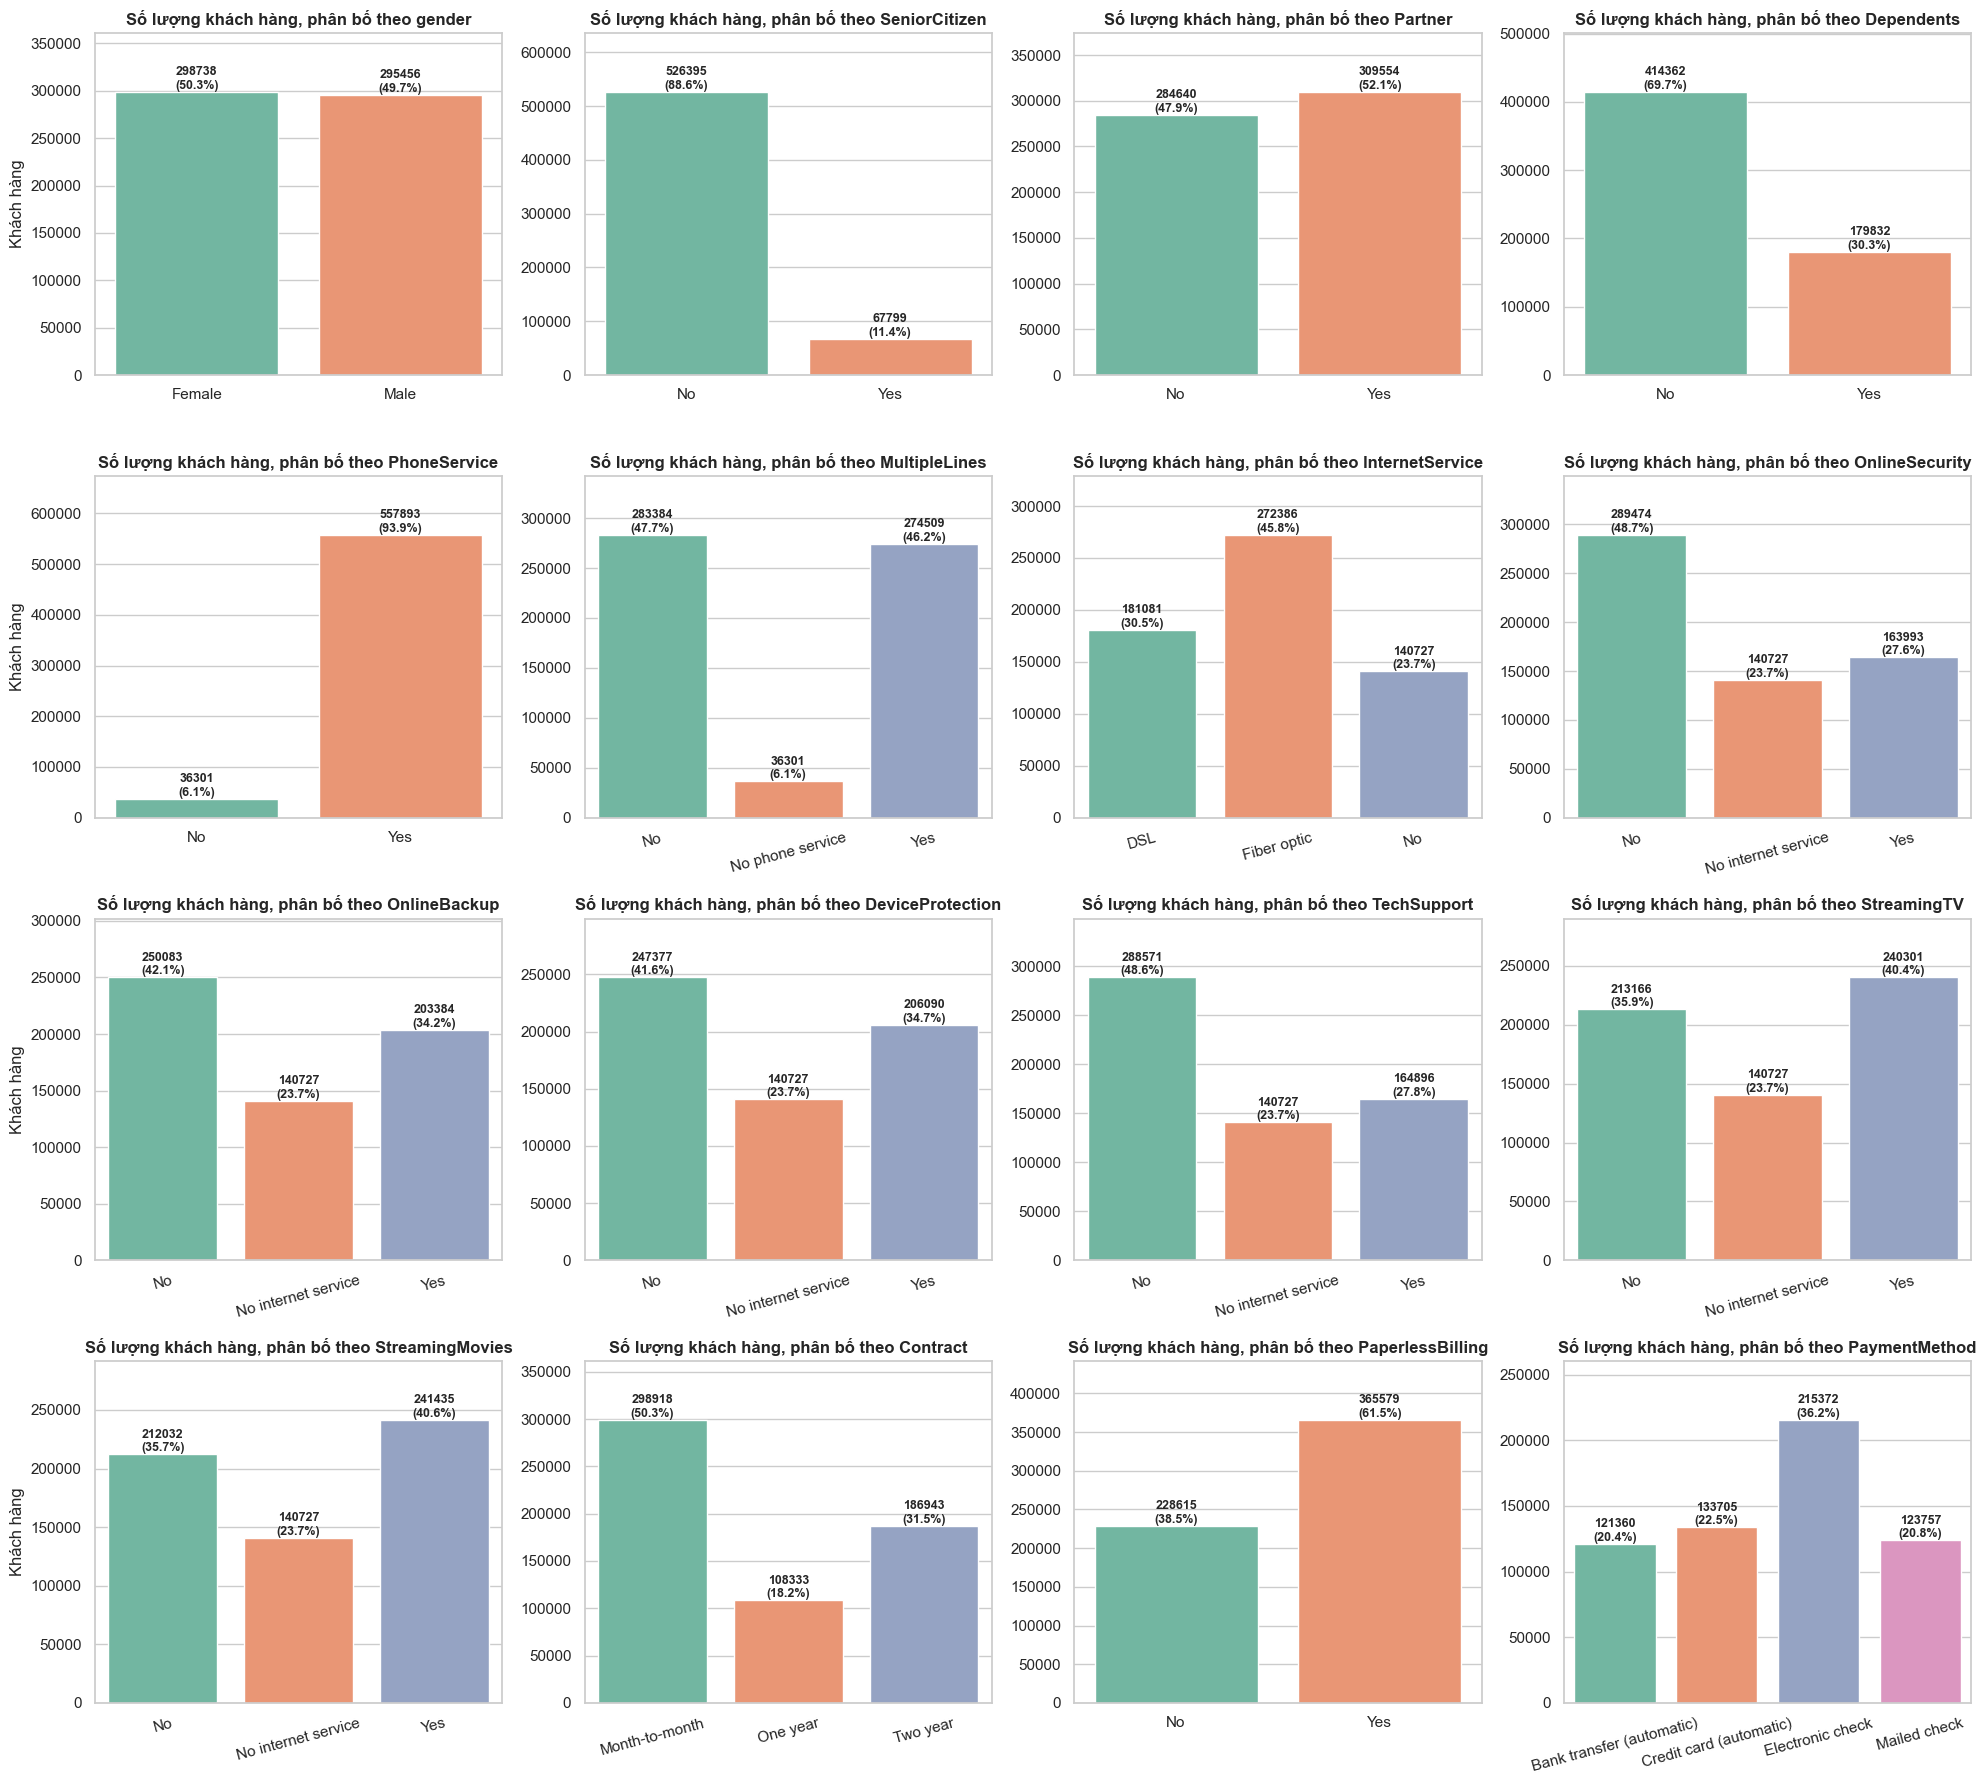

In [42]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))
axes = axes.flatten() 

for i, col in enumerate(categorical_features):
    category_order = sorted(df_train_copy[col].dropna().unique())
    
    sns.countplot(data=df_train_copy, x=col, hue=col, 
                  order=category_order, hue_order=category_order, 
                  ax=axes[i], palette='Set2', legend=False)

    total = len(df_train_copy[col].dropna())
    for p in axes[i].patches:
        count = int(p.get_height())
        pct = count / total * 100
        axes[i].annotate(
            f'{count}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )
    
    ymax = axes[i].get_ylim()[1]
    axes[i].set_ylim(0, ymax * 1.15)
    axes[i].set_title(f'Số lượng khách hàng, phân bố theo {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Khách hàng' if i % 4 == 0 else '') 
    
    if df_train_copy[col].nunique() > 2:
        axes[i].tick_params(axis='x', rotation=15)

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [62]:
rows = []
for i, col in enumerate(categorical_features, start=1):
    counts = df_train_copy[col].value_counts(dropna=False)
    rows.append({
        "STT": i,
        "Tên biến (Feature)": col,
        "Số giá trị phân biệt": df_train_copy[col].nunique(dropna=False),
        "Giá trị áp đảo": counts.index[0],
        "Tỷ lệ tương ứng": counts.iloc[0] / len(df_train_copy) * 100,
        "Số giá trị hiếm (< 1%)": int((counts / len(df_train_copy) < 0.01).sum()),
    })

cat_summary = pd.DataFrame(rows)

display(cat_summary.style.format({'Tỷ lệ tương ứng': '{:.2f}%'}).hide(axis="index"))

STT,Tên biến (Feature),Số giá trị phân biệt,Giá trị áp đảo,Tỷ lệ tương ứng,Số giá trị hiếm (< 1%)
1,gender,2,0,50.28%,0
2,SeniorCitizen,2,0,88.59%,0
3,Partner,2,1,52.10%,0
4,Dependents,2,0,69.74%,0
5,PhoneService,2,1,93.89%,0
6,MultipleLines,2,0,53.80%,0
7,InternetService,3,Fiber optic,45.84%,0
8,OnlineSecurity,2,0,72.40%,0
9,OnlineBackup,2,0,65.77%,0
10,DeviceProtection,2,0,65.32%,0


**Nhận xét:**
  - **Không xuất hiện giá trị hiếm:** Không có nhóm nào xuất hiện ít hơn $1\%$ tổng số dòng dữ liệu.
  - **Giá trị áp đảo:** Biến `PhoneService` có hiện tượng mất cân bằng cực hạn khi nhóm `Yes` chiếm tới $93.89\%$.

**Kết luận:**
  * **Chiến lược Encoding:** Vì tất cả các biến định tính đều có độ phân nhánh thấp (Low-Cardinality Features) , phương pháp **One-Hot Encoding** có thể được áp dụng một cách an toàn cho toàn bộ các biến định tính, không gặp nguy cơ bùng nổ số lượng cột (Curse of Dimensionality).
  * **Xử lý nhóm hiếm:** Không cần thực hiện các kỹ thuật gộp nhóm hiếm (như Rare Label Encoding) vì không tồn tại nhóm nào có tỷ lệ dưới 1%.
  * **Lưu ý mô hình:** Cột `PhoneService` có độ phân hóa cực kỳ thấp (hầu như ai cũng dùng). Cần đối chiếu thêm với biểu đồ tỉ lệ Churn nhằm xem xét tính giá trị trong việc dự báo cho mô hình, có thể xem xét loại bỏ nếu không tạo ra sự phân tách hành vi khách hàng.

### 4.3 Phân tích sơ bộ hành vi khách hàng (Churn Analysis) 

**Note:** Việc thực hiện phân tích sơ bộ hành vi khách hàng nhằm
1. Đánh giá tỷ lệ phân bố giữa nhóm khách hàng tiếp tục sử dụng (`No`) và nhóm rời bỏ dịch vụ (`Yes`) nhằm xác định mức độ mất cân bằng dữ liệu (Imbalanced Data)
2. Thông qua các đánh giá để xác định chiến lược phân tách tập mẫu và lựa chọn thước đo đánh giá mô hình (Evaluation Metric) phù hợp.

**Trực quan hóa phân bố khách hàng rời bỏ dịch vụ**

In [44]:
total = len(df_train_copy)
churn_counts = df_train_copy['Churn'].value_counts().sort_index()
churn_pct = churn_counts / total * 100
labels = ['Tiếp tục sử dụng dịch vụ', 'Dừng sử dụng dịch vụ']

summary = pd.DataFrame({
    'Churn': [0, 1],
    'count': churn_counts.values,
    'pct':   churn_pct.values
})

**Note:** Đầu tiên ta bắt đầu với việc trực quan hóa phân bố khách hàng rời bỏ dịch vụ, theo biến `Churn`

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.close(fig)

**Note:** Ta thực hiện trực quan hóa phân bố này theo hai hướng
1. Tỷ lệ khách hàng rời bỏ dịch vụ, theo biểu đồ tròn (Pie Chart)
2. Số lượng khách hàng rời bỏ dịch vụ, theo biểu đồ cột (Bar Chart)

In [46]:
churn_counts = df_train_copy['Churn'].value_counts()
pie_labels = ["Dừng sử dụng dịch vụ" if val == "Yes" else "Tiếp tục sử dụng dịch vụ" for val in churn_counts.index]

ax1.pie(churn_counts, labels=pie_labels, autopct='%1.1f%%', 
        startangle=90, colors=['#81b29a', '#e07a5f'], 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax1.set_title('Tỷ lệ khách hàng rời bỏ dịch vụ', fontsize=14, fontweight='bold');

**Note:** Biểu đồ tròn này giúp ta thấy rõ hơn sự chênh lệch tỷ lệ giữa nhóm khách hàng Dừng sử dụng dịch vụ và Tiếp tục sử dụng dịch vụ

In [47]:
sns.countplot(data=df_train_copy, x='Churn', hue='Churn', palette=['#81b29a', '#e07a5f'], legend=False, ax=ax2)

x_labels = [label.get_text() for label in ax2.get_xticklabels()]
bar_labels = ["Dừng sử dụng dịch vụ" if label == "Yes" else "Tiếp tục sử dụng dịch vụ" for label in x_labels]
ax2.set_xticks(ax2.get_xticks()) 
ax2.set_xticklabels(bar_labels)

ax2.set_title('Số lượng khách hàng rời bỏ dịch vụ', fontsize=14, fontweight='bold')
ax2.set_ylabel('Khách hàng')
ax2.set_xlabel('')

current_ylim = ax2.get_ylim()
ax2.set_ylim(0, current_ylim[1] * 1.15) 

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, fontweight='bold', 
                color='black', xytext=(0, 5), textcoords='offset points')

**Note:** Biểu đồ cột này giúp ta thấy rõ hơn sự chênh lệch số lượng giữa nhóm khách hàng Dừng sử dụng dịch vụ và Tiếp tục sử dụng dịch vụ

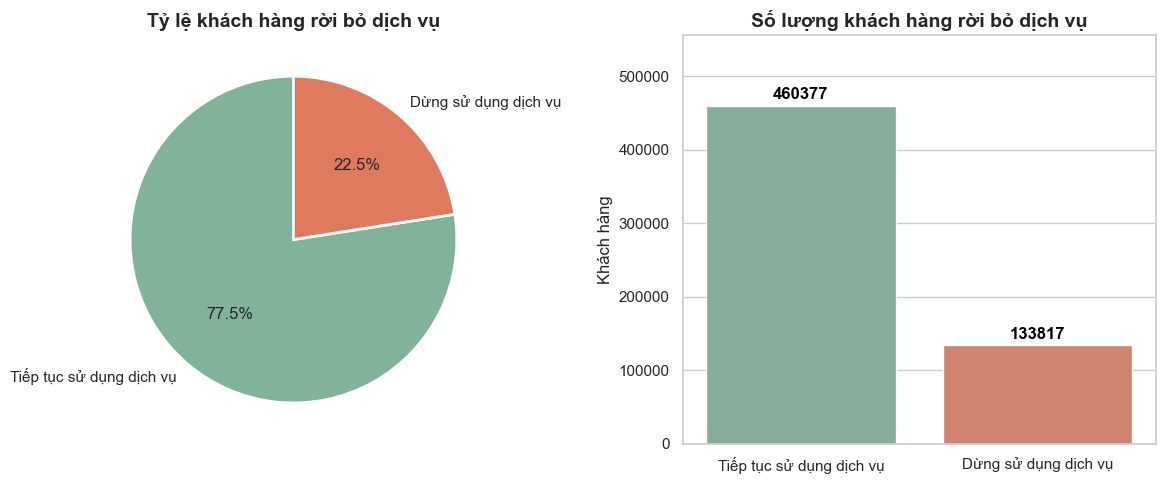

In [48]:
fig.tight_layout()
fig

**Nhận xét:** Dữ liệu thể hiện sự mất cân bằng mẫu ở mức độ vừa phải (tỷ lệ xấp xỉ $3.5 : 1$). Cụ thể:
- Nhóm khách hàng ở lại (`No`) chiếm đa số với $77.5\%$ (460,377 khách hàng).
- Nhóm khách hàng rời bỏ (`Yes`) - nhóm thiểu số cần dự đoán - chỉ chiếm $22.5\%$ (133,817 khách hàng).


**Kết luận**
Sự mất cân bằng dữ liệu như trên đặt ra 3 quy tắc bắt buộc:
* **Thước đo đánh giá** (Evaluation Metric): Không thể sử dụng `Accuracy` (Độ chính xác tổng thể) vì mô hình có thể đạt điểm cao một cách sai lệch khi đưa ra dự đoán tất cả là `No`. Yêu cầu bắt buộc là phải sử dụng **ROC-AUC** làm thước đo chính để tối ưu hóa khả năng xếp hạng rủi ro (ranking churn risk) của mô hình.
* **Chiến lược Validation**: Yêu cầu bắt buộc sử dụng kỹ thuật phân tầng (**Stratified K-Fold**) khi chia tập Train/Validation để đảm bảo tỷ lệ 22.5% nhóm `Yes` được giữ nguyên vẹn trên mọi nếp gấp (fold).
* **Feature Engineering & Loss Function:** Cần tập trung khai thác các biến có tính phân hóa mạnh, để giúp mô hình dễ dàng phát hiện các đặc điểm của nhóm thiểu số. Có thể cân nhắc điều chỉnh hàm mất mát (như dùng `scale_pos_weight` trong XGBoost) để tránh hiện tượng thuật toán bị thiên lệch (bias) về phía nhóm số đông.

## 5. Phân tích tương quan (Correlation Analysis)

### 5.1 Phân tích tương quan giữa các biến định tính và biến mục tiêu (Categorical Feature-Churn Correlation Analysis)

**Note:** Như đã nhắc đến ở trên, ta chia biến định tính thành 3 loại 
- Các biến định tính mang hai giá trị phân biệt là `Yes` và `No` được phân vào nhóm `Binary Features`
- Các biến định tính mang nhiều hơn hai giá trị phân biệt là `Yes` và `No`, nhưng dựa trên đặc thù vẫn có thể đưa về như biến trên được phân vào nhóm `Nearly-Binary Features`
- Các biến định tính phức tạp hơn hai loại trên được xếp vào nhóm thứ ba, nhóm biến định tính phức tạp có độ phân nhánh thấp(Low-Cardinality Features)

**Phân tích và trực quan hóa tương quan giữa các biến định tính `Binary Features` và `Nearly-Binary Features` so với biến mục tiêu `Churn`**

In [49]:
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']
for col in binary_cols:
    df_train_copy[col] = df_train_copy[col].replace({'Yes': 1, 'No': 0})

df_train_copy['gender'] = df_train_copy['gender'].replace({'Male': 1, 'Female': 0})

nearly_binary_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in nearly_binary_cols:
    df_train_copy[col] = df_train_copy[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df_train_copy[col] = df_train_copy[col].replace({'Yes': 1, 'No': 0})

cols_to_corr = binary_cols + nearly_binary_cols + ['gender']

**Note:** Thực hiện đồng nhất các biến định tính `Nearly-Binary Features` thành `Binary Features` để phân tích và trực quan hóa tương quan

In [50]:
corr_matrix = df_train_copy[cols_to_corr].astype(float).corr(method='spearman')

**Note:** Phương pháp Spearman được chọn thay vì Kendall vì với dataset có kích thước lớn, Kendall tính toán chậm hơn đáng kể (độ phức tạp O(n²) so với O(n log n) của Spearman) mà không mang lại cải thiện đáng kể về độ chính xác. Thay vì Pearson vì dữ liệu chứa nhiều biến nhị phân không thỏa giả định tuyến tính. Do đó Spearman là lựa chọn cân bằng tốt nhất giữa tính phù hợp với dữ liệu và hiệu quả tính toán trong trường hợp này.

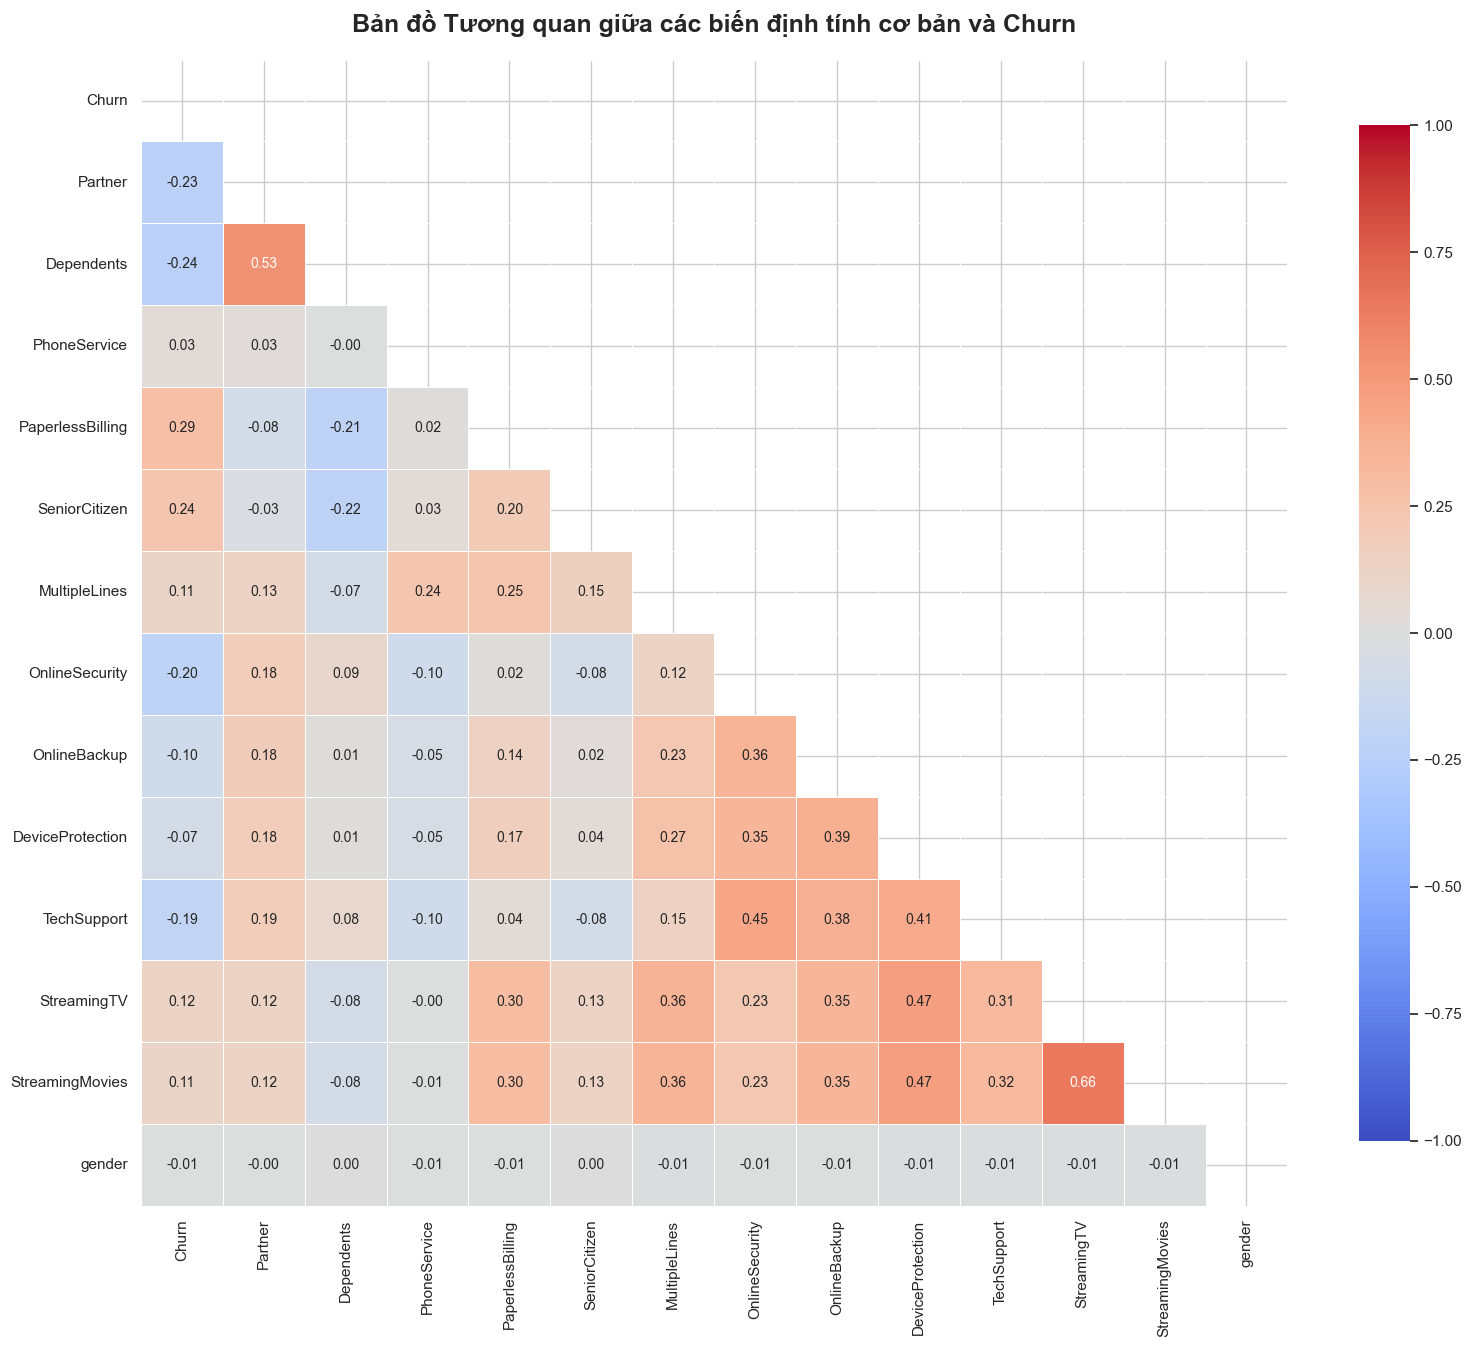

In [51]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 14))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10}
)

plt.title('Bản đồ Tương quan giữa các biến định tính cơ bản và Churn', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Note:** Ngoài yếu tố tương quan giữa biến `Churn` và nhóm biến `Binary`,`Nearly-Binary` ta cũng xem xét từng cặp biến trong nhóm này để phát hiện ra các **Cụm đa cộng tuyến**(Tương quan nội bộ mạnh giữa các biến độc lập):
- Biến `StreamingTV` và `StreamingMovies` có hệ số tương quan rất cao, đạt $0.66$.
- Biến `Partner` và `Dependents` có hệ số tương quan cao, đạt $0.53$.
- Các biến `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport` tương quan chặt chẽ từng đôi một với các hệ số tương quan dao động từ $0.35$ đến $0.47$.


**Nhận xét:**
  - **Xử lý đa cộng tuyến:** Do `StreamingTV` và `StreamingMovies` tương quan với hệ số rất cao ($0.66$), khi đưa vào các mô hình hồi quy (như Logistic Regression), có thể gộp chúng lại thành một biến đếm tổng hợp để không gây sai lệch trong quá trình dự đoán.
  -  **Tối ưu hóa cụm tiện ích:** Sự tương quan với hệ số cao đồng đều (khoảng từ $0.35$ đến $0.47$) trong cụm dịch vụ bảo mật/hỗ trợ kỹ thuật mở ra ý tưởng về một tính năng mới tích hợp dạng điểm số nhằm đại diện cho mức độ cam kết gắn bó của khách hàng.

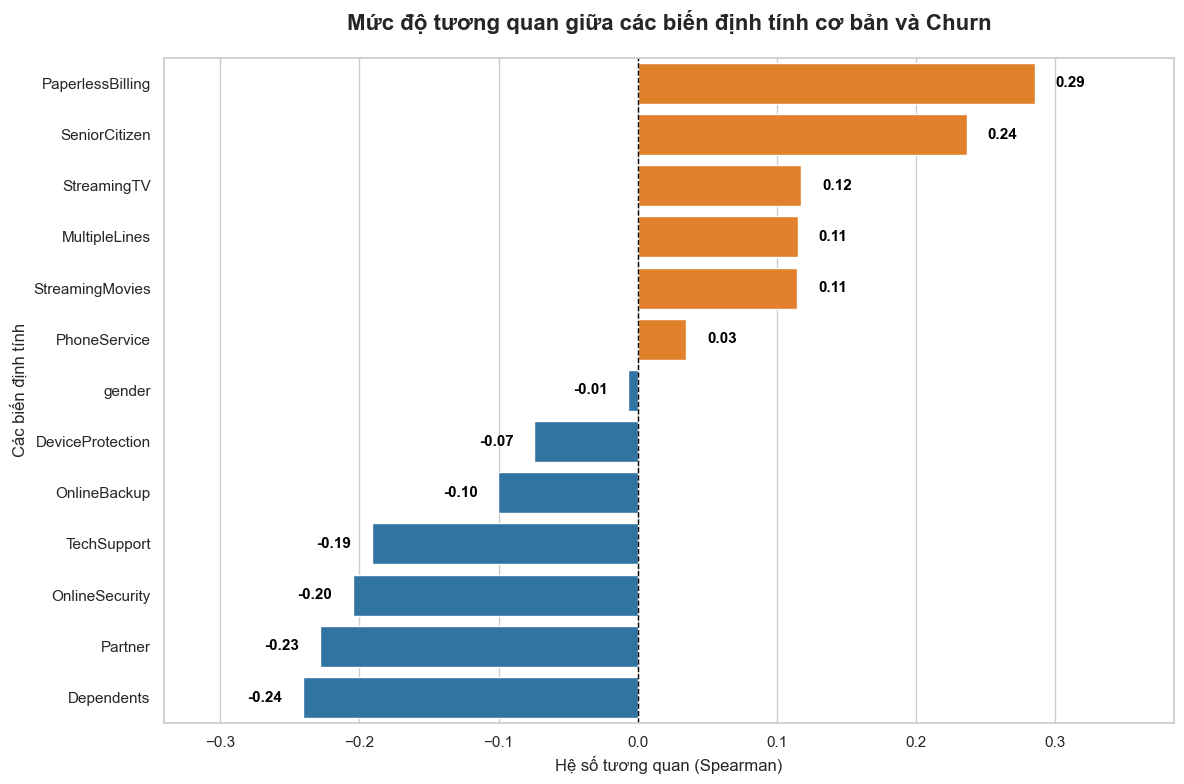

In [52]:
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)
colors = ['#FF7F0E' if val > 0 else '#1F77B4' for val in churn_corr.values]

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=churn_corr.values, 
    y=churn_corr.index, 
    hue=churn_corr.index,
    palette=colors,
    legend=False
)

plt.title('Mức độ tương quan giữa các biến định tính cơ bản và Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hệ số tương quan (Spearman)', fontsize=12)
plt.ylabel('Các biến định tính', fontsize=12)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

for i, val in enumerate(churn_corr.values):
    ax.text(val + (0.015 if val > 0 else -0.015), i, f'{val:.2f}', 
            va='center', ha='left' if val > 0 else 'right', 
            fontsize=11, fontweight='bold', color='black')

plt.xlim(churn_corr.min() - 0.1, churn_corr.max() + 0.1)

plt.tight_layout()
plt.show()

**Note:** Sau khi xem xét sự tương quan giữa từng cặp biến trong nhóm, ta trực quan hóa sự tương quan giữa biến `Churn` và từng biến trong nhóm để tìm ra những đặc điểm nổi bật nhất
- Tương quan dương: Biến `PaperlessBilling` ($0.29$) và `SeniorCitizen` ($0.24$) mang đặc tính tỷ lệ thuận rõ rệt nhất với biến mục tiêu `Churn`.
- Tương quan âm: Biến `Dependents` ($-0.24$) và `Partner` ($-0.23$) mang đặc tính tỷ lệ nghịch lớn nhất với biến mục tiêu `Churn` .

In [53]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    k = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * k))

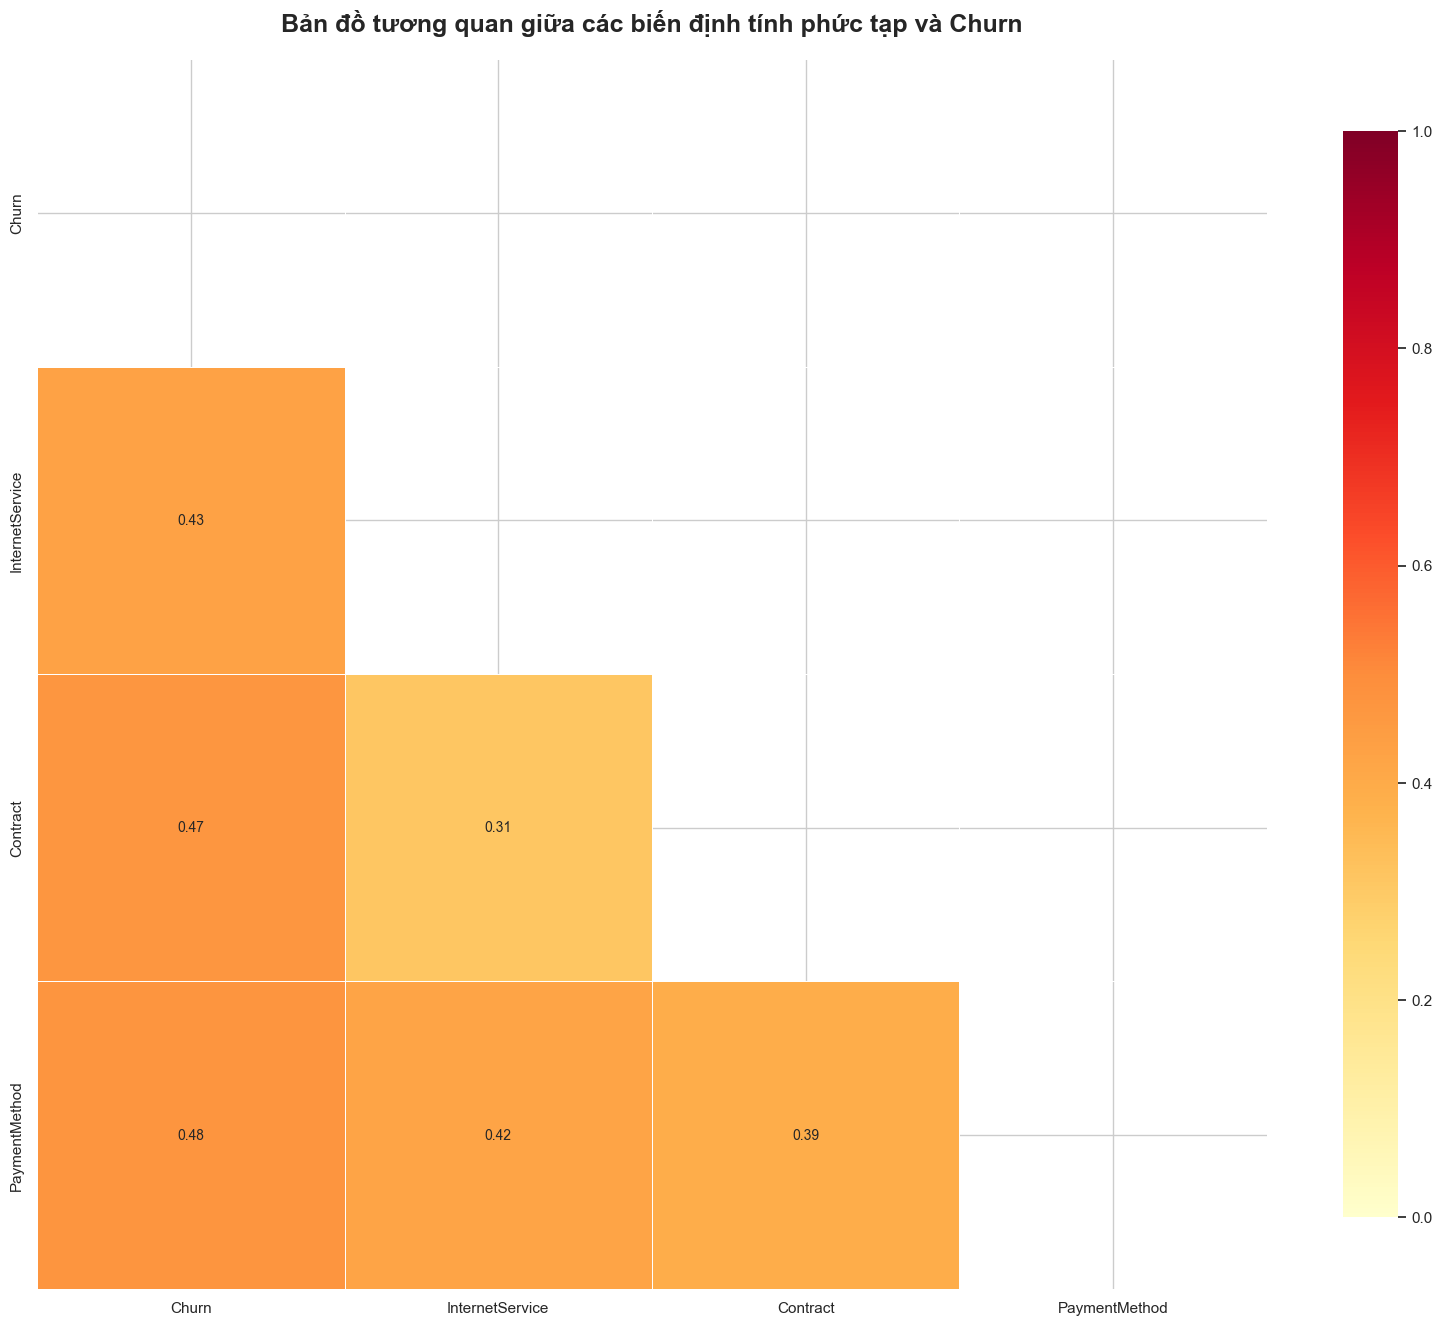

In [54]:
multi_cols = ['Churn', 'InternetService', 'Contract', 'PaymentMethod']

cramers_matrix = pd.DataFrame(index=multi_cols, columns=multi_cols, dtype=float)

for col1 in multi_cols:
    for col2 in multi_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(
                df_train_copy[col1].astype(str),
                df_train_copy[col2].astype(str)
            )


mask = np.triu(np.ones_like(cramers_matrix, dtype=bool))
plt.figure(figsize=(16, 14))

sns.heatmap(
    cramers_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='YlOrRd',
    vmin=0, vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10}
)

plt.title("Bản đồ tương quan giữa các biến định tính phức tạp và Churn", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

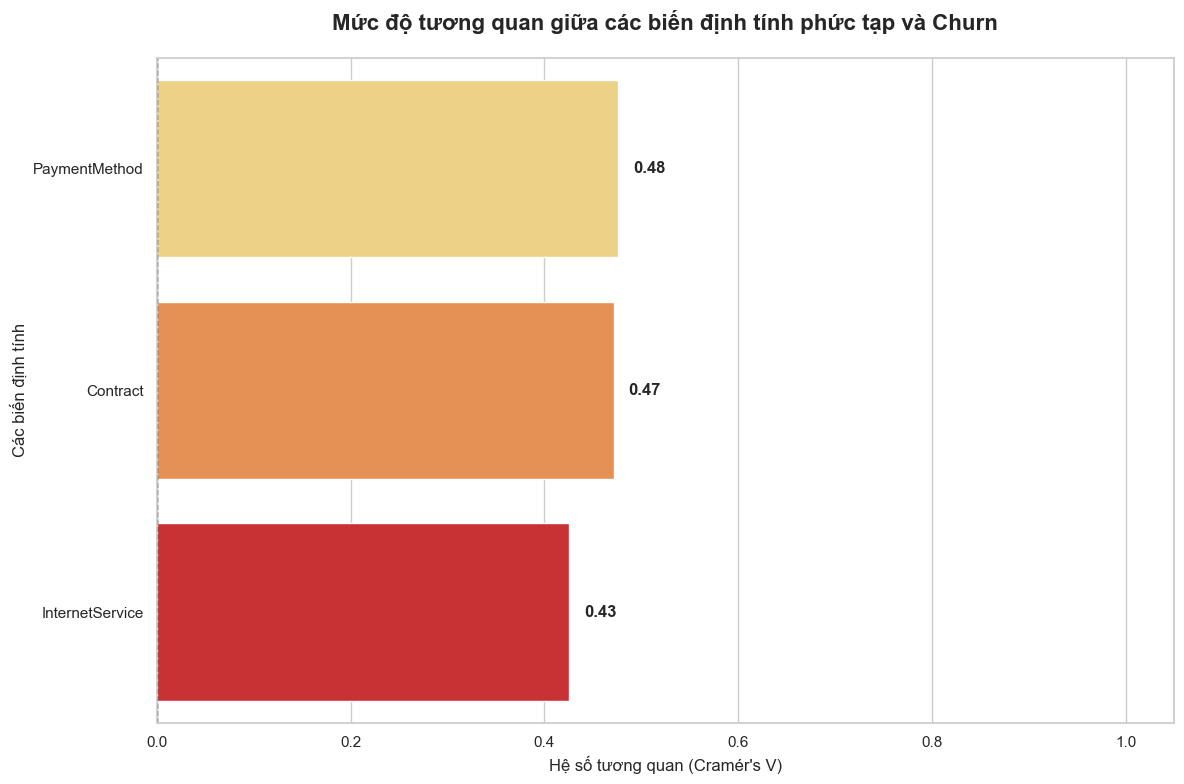

In [ ]:
churn_cramers = cramers_matrix['Churn'].drop('Churn').sort_values(ascending=False)
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=churn_cramers.values,
    y=churn_cramers.index,
    hue=churn_cramers.index,
    palette='YlOrRd',
    legend=False
)


plt.title("Mức độ tương quan giữa các biến định tính phức tạp và Churn", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Hệ số tương quan (Cramér's V)", fontsize=12)
plt.ylabel('Các biến định tính', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlim(0, 1.05)

for i, val in enumerate(churn_cramers.values):
    ax.text(val + 0.015, i, f'{val:.2f}',
            va='center', ha='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

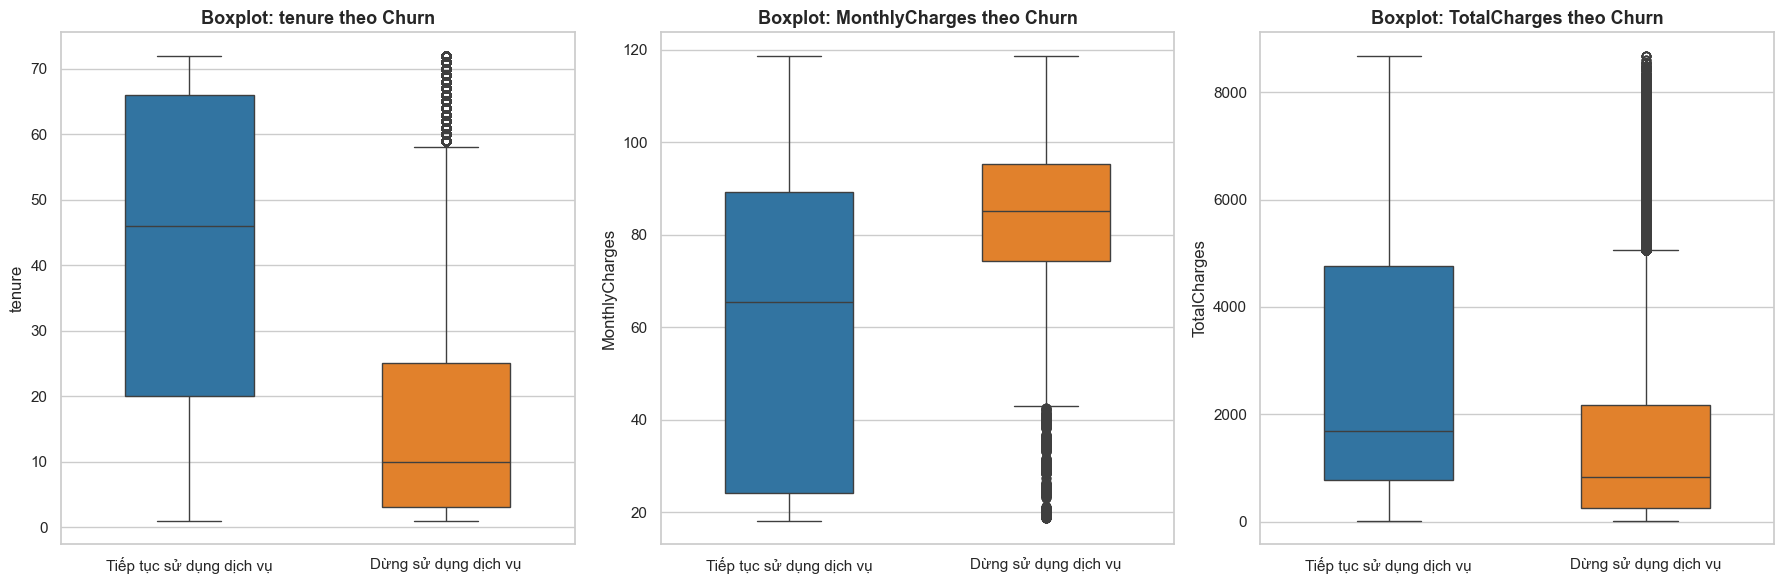

In [56]:
quant_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, col in enumerate(quant_cols):
    sns.boxplot(
        data=df_train_copy, x='Churn', y=col,
        hue='Churn',
        palette=['#1F77B4', '#FF7F0E'],
        legend=False,
        ax=axes[i], width=0.5
    )
    axes[i].set_title(f'Boxplot: {col} theo Churn', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Tiếp tục sử dụng dịch vụ', 'Dừng sử dụng dịch vụ'])

plt.tight_layout()
plt.show()

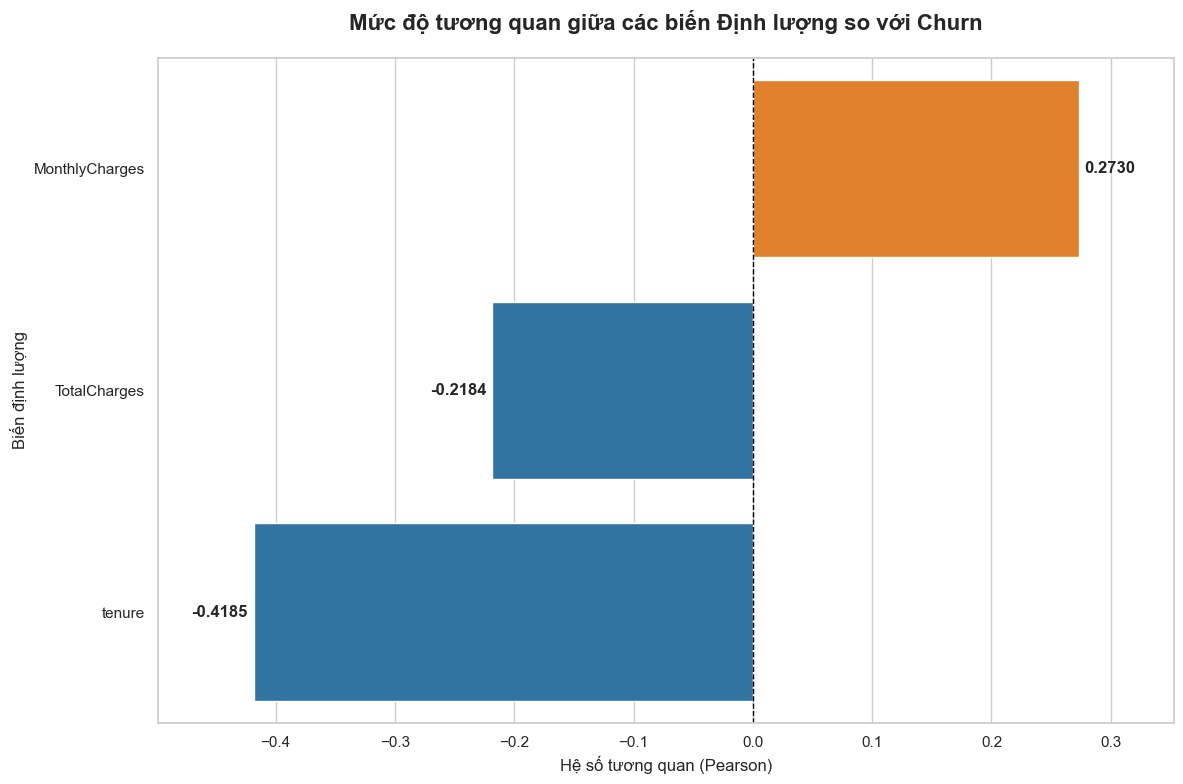

In [57]:
corr_quant = df_train_copy[quant_cols + ['Churn']].corr()['Churn'].drop('Churn').sort_values(ascending=False)

colors = ['#FF7F0E' if v > 0 else '#1F77B4' for v in corr_quant.values]

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=corr_quant.values, y=corr_quant.index,
    hue=corr_quant.index, palette=colors, legend=False
)

plt.title('Mức độ tương quan giữa các biến Định lượng so với Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hệ số tương quan (Pearson)', fontsize=12)
plt.ylabel('Biến định lượng', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

for i, val in enumerate(corr_quant.values):
    ax.text(val + (0.005 if val > 0 else -0.005), i, f'{val:.4f}',
            va='center', ha='left' if val > 0 else 'right',
            fontsize=12, fontweight='bold')

plt.xlim(corr_quant.min() - 0.08, corr_quant.max() + 0.08)
plt.tight_layout()
plt.show()